In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import classification_report
from sklearn.linear_model import RidgeCV
from sklearn.metrics import f1_score
from sklearn.metrics import pairwise_distances


# Load the Data

In [30]:
with np.load("../../outputs/segmented_embeddings/siglip2-so400m-14-384_clahe_embeddings.npz") as data:
    emb = data["features"]
    age = data["labels"]
    meId = data["measurement_ids"]

meta = pd.read_csv("../../cod_otolith_age_final_with_scale.csv")[[
    "measurement_id",
    "age", "length",
    "month", "month_cos", "month_sin",
    "seg_width_px",
    "seg_height_px",
    "seg_aspect_ratio",
    ]]

meta = meta[meta["measurement_id"].isin(meId)]


X_train, X_test, y_train, y_test = train_test_split(
    emb, age, test_size=0.15, random_state=81, stratify=age
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Embedding shapes:", emb.shape, "\nAge shapes:", age.shape)


Embedding shapes: (8619, 1152) 
Age shapes: (8619,)


# Maturity Axis (fit to min max age)


In [31]:
# Identify extreme ages
unique_ages = np.unique(age)
min_age, max_age = min(unique_ages), max(unique_ages)
print(f"Unique ages: {unique_ages}")

Unique ages: [ 1  2  3  4  5  6  7  8  9 10]


In [32]:
# Calculate Prototypes
proto_young = np.mean(emb[age == min_age], axis=0)
proto_old = np.mean(emb[age == max_age], axis=0)

# Define the Age Direction Vector (normalized)
age_direction = proto_old-proto_young
age_direction = age_direction / np.linalg.norm(age_direction)

# Projection of ALL the embeddings in this axis
## Dot product between each embeddding and the direction vector
projections = np.dot(emb, age_direction)

# Calculate the Residuals (To remove the age component)
# residuals = original - (projection * direction vec.)
age_components = np.outer(projections, age_direction)
res = emb - age_components

# We want

In [34]:
# Validate signal: Average of real scores per real group

print("Average Projection per Real Age:")
for a in np.unique(age):
    mean_proj = projections[age == a].mean()
    print(f"Age {a}: {mean_proj:.4f}")


Average Projection per Real Age:
Age 1: -0.1684
Age 2: -0.0087
Age 3: 0.0981
Age 4: 0.1477
Age 5: 0.1776
Age 6: 0.2006
Age 7: 0.2234
Age 8: 0.2520
Age 9: 0.2589
Age 10: 0.2847


/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_23413/3968246982.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=age_scores, palette="viridis")


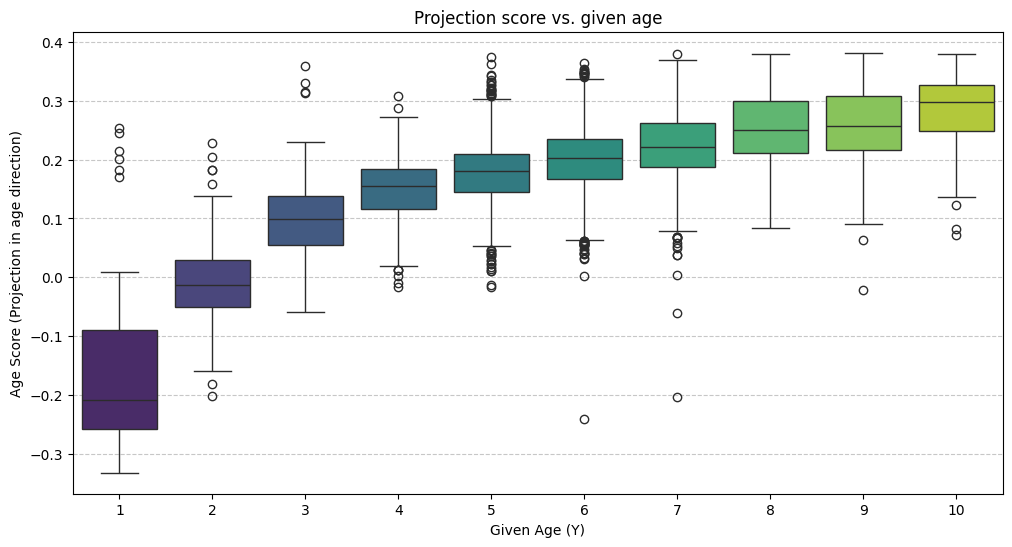

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_age_distribution(age_scores, labels):
    plt.figure(figsize=(12, 6))

    # Criar o Boxplot com um Swarmplot por cima (opcional, para ver a densidade)
    sns.boxplot(x=labels, y=age_scores, palette="viridis")

    plt.title("Projection score vs. given age")
    plt.xlabel("Given Age (Y)")
    plt.ylabel("Age Score (Projection in age direction)")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Usar os scores que calculaste antes
plot_age_distribution(projections, age)


# Linear Regression on this 1-axis of residuals

In [37]:


def analyze_age_direction(embeddings, labels):
    # Identify extreme ages
    unique_ages = np.unique(labels)
    min_age, max_age = np.min(unique_ages), np.max(unique_ages)

    # Calculate extreme means
    proto_young = embeddings[labels == min_age].mean(axis=0)
    proto_old = embeddings[labels == max_age].mean(axis=0)

    # Normalized Age Vector
    age_direction = proto_old - proto_young
    age_direction /= np.linalg.norm(age_direction)

    # Projection of ALL embeddings on this axis
    # (Dot product between each vector and the age vector)
    projections = dot_product = np.dot(embeddings, age_direction)

    # Compute the residuals (removing age signal)
    # residual = original - (projection * direction)
    age_components = np.outer(projections, age_direction)
    residuals = embeddings - age_components

    return age_direction, projections, residuals

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


emb_train, emb_test, y_train, y_test = train_test_split(
    emb, age, test_size=0.15, random_state=42, stratify=age
)

def get_age_direction(e, l):
    p_young = e[l == l.min()].mean(axis=0)
    p_old = e[l == l.max()].mean(axis=0)
    d = p_old - p_young
    return d / np.linalg.norm(d)

age_dir = get_age_direction(emb_train, y_train)

# 3. Gerar Scores (Projeção)
train_scores = np.dot(emb_train, age_dir).reshape(-1, 1)
test_scores = np.dot(emb_test, age_dir).reshape(-1, 1)

# 4. Treinar Regressão
reg = LinearRegression().fit(train_scores, y_train)

# 5. Avaliação Final
preds_test = reg.predict(test_scores)
class_pred = np.clip(np.round(preds_test), 1, 10)
mae = mean_absolute_error(y_test, preds_test)
acc = accuracy_score(y_test, class_pred)
print(f"Erro Médio no Test Set: {mae:.2f} anos")
print(f"Acurácia no Test Set: {acc*100:.2f}%")




Erro Médio no Test Set: 1.10 anos
Acurácia no Test Set: 29.54%


# Plotting Residuals

/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


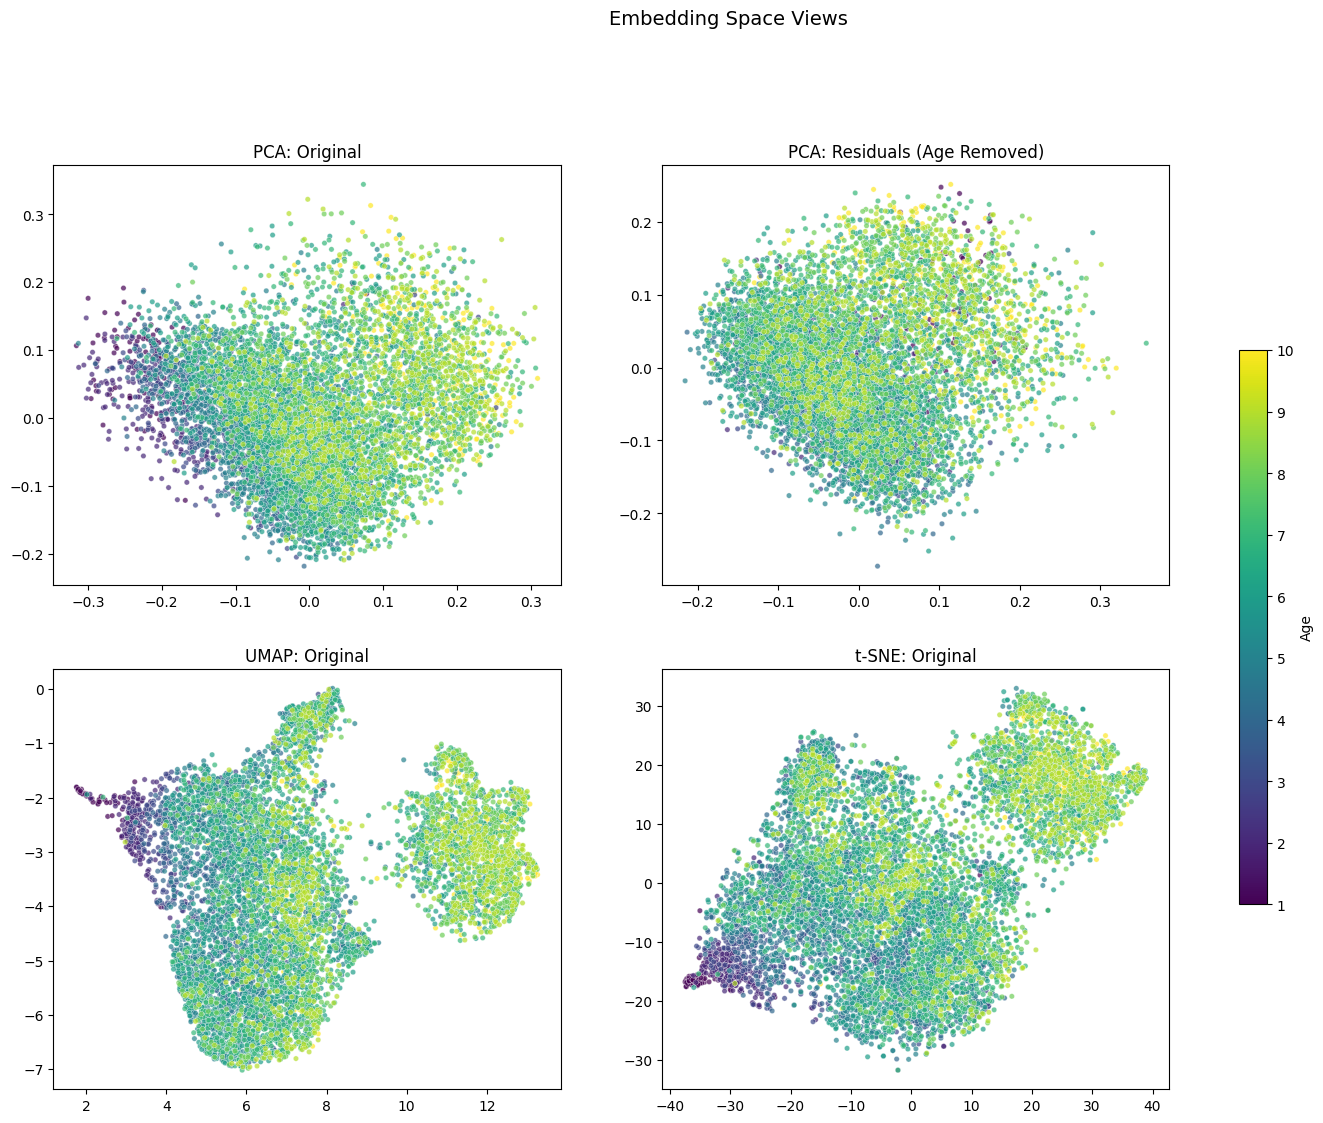

In [38]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
import seaborn as sns

def plot_embedding_views(original_emb, residuals, labels):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    configs = [
        ("PCA: Original", original_emb,
         PCA(n_components=2).fit_transform(original_emb)),

        ("PCA: Residuals (Age Removed)", residuals,
         PCA(n_components=2).fit_transform(residuals)),

        ("UMAP: Original", original_emb,
         umap.UMAP(n_components=2, metric="cosine",
                   n_neighbors=30, min_dist=0.1,
                   random_state=42).fit_transform(original_emb)),

        ("t-SNE: Original", original_emb,
         TSNE(n_components=2, metric="cosine",
              perplexity=85, random_state=42).fit_transform(original_emb)),
    ]

    for ax, (title, _, X_2d) in zip(axes, configs):
        sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                        hue=labels, palette="viridis",
                        ax=ax, s=15, alpha=0.7, legend=False)
        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # Single shared colorbar
    sm = plt.cm.ScalarMappable(cmap="viridis",
                                norm=plt.Normalize(vmin=min(labels),
                                                   vmax=max(labels)))
    fig.colorbar(sm, ax=axes, label="Age", shrink=0.6)
    plt.suptitle("Embedding Space Views", fontsize=14, y=1.01)
    plt.show()

plot_embedding_views(emb, res, age)

/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/oto-cod-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


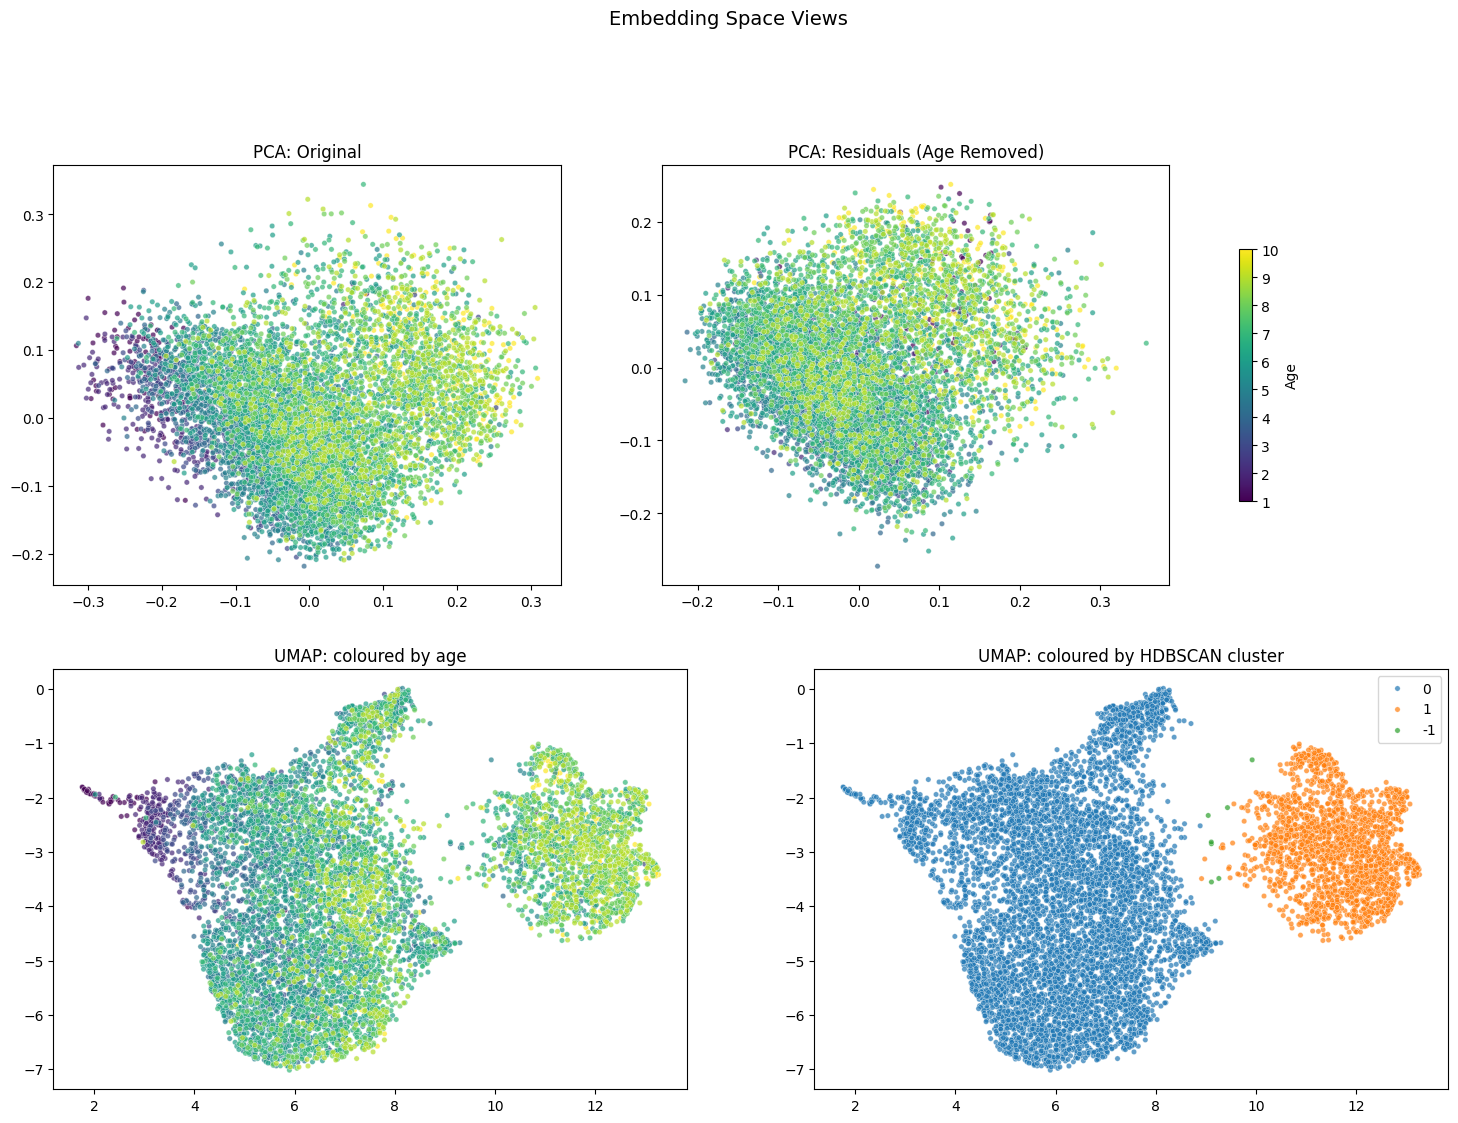

Cluster -1: n=7, mean age=6.57, median age=6.0
Cluster 0: n=6571, mean age=5.69, median age=6.0
Cluster 1: n=2041, mean age=7.74, median age=8.0


In [48]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap
import hdbscan
import seaborn as sns
import numpy as np

def plot_embedding_views(original_emb, residuals, labels):
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    umap_2d = umap.UMAP(n_components=2, metric="cosine",
                         n_neighbors=30, min_dist=0.1,
                         random_state=42).fit_transform(original_emb)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=50, min_samples=10)
    cluster_labels = clusterer.fit_predict(umap_2d)

    pca_orig = PCA(n_components=2).fit_transform(original_emb)
    pca_res  = PCA(n_components=2).fit_transform(residuals)

    configs = [
        ("PCA: Original",                  pca_orig,  "age"),
        ("PCA: Residuals (Age Removed)",   pca_res,   "age"),
        ("UMAP: coloured by age",          umap_2d,   "age"),
        ("UMAP: coloured by HDBSCAN cluster", umap_2d, "cluster"),
    ]

    for ax, (title, X_2d, colour_by) in zip(axes, configs):
        if colour_by == "cluster":
            sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                            hue=cluster_labels.astype(str),
                            palette="tab10", ax=ax, s=15, alpha=0.7)
        else:
            sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1],
                            hue=labels, palette="viridis",
                            ax=ax, s=15, alpha=0.7, legend=False)
        ax.set_title(title)

    sm = plt.cm.ScalarMappable(cmap="viridis",
                                norm=plt.Normalize(vmin=min(labels),
                                                   vmax=max(labels)))
    fig.colorbar(sm, ax=axes[:2], label="Age", shrink=0.6)
    plt.suptitle("Embedding Space Views", fontsize=14, y=1.01)
    
    plt.show()

    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        print(f"Cluster {c}: n={mask.sum()}, "
              f"mean age={labels[mask].mean():.2f}, "
              f"median age={np.median(labels[mask]):.1f}")

    return cluster_labels

cluster_labels = plot_embedding_views(emb, res, age)

Top 20 embedding dimensions driving cluster split:
[  12  435  849  240  217  722  531  466  378  289 1130  176  665  563
  546  206  989  521  654  579]
Their coefficients: [ 6.43291852  3.70452581 -3.56451412  3.36809076 -3.3396052   3.21393149
 -3.16297431  3.13793238 -2.84382044  2.71460563 -2.60214093 -2.55789973
  2.51567635 -2.50979332 -2.46188163 -2.44919093  2.39742496 -2.38005
 -2.35272132  2.34614877]


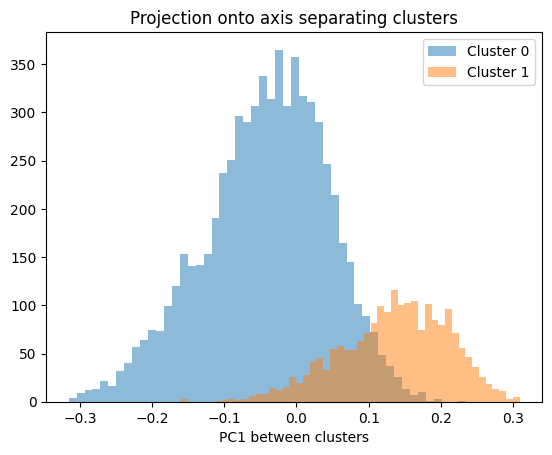

In [49]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Train a linear classifier to separate the two clusters
mask = cluster_labels >= 0  # exclude noise points
X_clean = emb[mask]
y_clean = cluster_labels[mask]

clf = LogisticRegression(max_iter=1000).fit(X_clean, y_clean)

# Top dimensions driving the separation
coef = clf.coef_[0]
top_dims = np.argsort(np.abs(coef))[::-1][:20]
print("Top 20 embedding dimensions driving cluster split:")
print(top_dims)
print("Their coefficients:", coef[top_dims])

# Also check: is the separation sharp or gradual?
from sklearn.decomposition import PCA
pca = PCA(n_components=1)
proj = pca.fit_transform(X_clean)
plt.hist(proj[y_clean==0], bins=50, alpha=0.5, label='Cluster 0')
plt.hist(proj[y_clean==1], bins=50, alpha=0.5, label='Cluster 1')
plt.xlabel('PC1 between clusters')
plt.legend()
plt.title('Projection onto axis separating clusters')
plt.show()


# Baseline RidgeCV + SVM CV

## Ridge Regression

In [50]:
ridge_cv = RidgeCV(
    cv = 5,
    alphas=np.logspace(-1, 3.0, 50)
    ).fit(X_train_scaled, y_train)
print(f"{ridge_cv.alpha_=}")

y_pred = np.clip(np.round(ridge_cv.predict(X_test_scaled)), 1, 10)

print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.08944e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.06179e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.03621e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07403e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/python3.12/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.07858e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/usr/local/lib/pytho

ridge_cv.alpha_=np.float64(390.6939937054613)
              precision    recall  f1-score   support

           1       0.53      0.50      0.52        16
           2       0.74      0.61      0.67        33
           3       0.57      0.48      0.52        52
           4       0.50      0.53      0.51       114
           5       0.58      0.49      0.53       254
           6       0.51      0.54      0.52       291
           7       0.46      0.62      0.53       222
           8       0.36      0.45      0.40       139
           9       0.47      0.33      0.39       110
          10       0.83      0.31      0.45        62

    accuracy                           0.50      1293
   macro avg       0.56      0.48      0.50      1293
weighted avg       0.52      0.50      0.50      1293



## SVC

In [49]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Recompute gamma for raw embedding space
idx = np.random.choice(len(X_train_scaled), size=1000, replace=False)
D = pairwise_distances(X_train_scaled[idx])
upper = D[np.triu_indices_from(D, k=1)]
median_dist = np.median(upper)
init_gamma = 1 / (median_dist ** 2)
print(f"Embedding-space gamma: {init_gamma:.4f}")

param_grid = {
    "C": [1.0, 10.0, 100.0],
    "gamma": [init_gamma * f for f in [0.5, 1.0, 2.0]],
}

gs = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)


gs.fit(X_train_scaled, y_train)
print("Best params:", gs.best_params_)
print(f"Best CV macro F1: {gs.best_score_:.4f}")

y_pred = gs.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

Embedding-space gamma: 0.0005
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'C': 10.0, 'gamma': np.float32(0.00023498939)}
Best CV macro F1: 0.5599
              precision    recall  f1-score   support

           1       1.00      0.69      0.81        16
           2       0.76      0.88      0.82        33
           3       0.69      0.60      0.64        52
           4       0.54      0.49      0.51       114
           5       0.56      0.60      0.58       254
           6       0.50      0.56      0.53       291
           7       0.44      0.46      0.45       222
           8       0.38      0.35      0.36       139
           9       0.57      0.47      0.51       110
          10       0.67      0.47      0.55        62

    accuracy                           0.52      1293
   macro avg       0.61      0.56      0.58      1293
weighted avg       0.52      0.52      0.52      1293



## SVR

In [ ]:
from sklearn.svm import SVR
import numpy as np

# Same gamma heuristic as SVC
idx = np.random.choice(len(X_train_scaled), size=1000, replace=False)
D = pairwise_distances(X_train_scaled[idx])
upper = D[np.triu_indices_from(D, k=1)]
median_dist = np.median(upper)
init_gamma = 1 / (median_dist ** 2)
print(f"Embedding-space gamma: {init_gamma:.4f}")

param_grid = {
    "C": [1.0, 10.0, 100.0],
    "epsilon": [0.1, 0.5, 1.0],  # epsilon-tube width in age units
    "gamma": [init_gamma * f for f in [0.5, 1.0, 2.0]],
}

gs = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",  # MAE makes sense for ordinal age
    n_jobs=-1,
    verbose=1,
)

gs.fit(X_train_scaled, y_train)
print("Best params:", gs.best_params_)
print(f"Best CV MAE: {-gs.best_score_:.4f}")

# Predict, clip to valid age range, round to nearest integer
y_pred_cont = gs.predict(X_test_scaled)
y_pred = np.clip(np.round(y_pred_cont).astype(int), 1, 10)

# MAE
mae = np.mean(np.abs(y_pred - y_test))
print(f"Test MAE: {mae:.4f}")

# Within-1 accuracy
within1 = np.mean(np.abs(y_pred - y_test) <= 1)
print(f"Within-1 accuracy: {within1:.4f}")

print(classification_report(y_test, y_pred))

Embedding-space gamma: 0.0005
Fitting 5 folds for each of 27 candidates, totalling 135 fits


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.56      0.56      0.56        16
           2       0.72      0.70      0.71        33
           3       0.74      0.54      0.62        52
           4       0.53      0.54      0.53       114
           5       0.58      0.54      0.56       254
           6       0.50      0.52      0.51       291
           7       0.44      0.50      0.47       222
           8       0.38      0.47      0.42       139
           9       0.48      0.38      0.43       110
          10       0.67      0.35      0.46        62

    accuracy                           0.50      1293
   macro avg       0.56      0.51      0.53      1293
weighted avg       0.52      0.50      0.50      1293



# Linear Descriminant Analysis

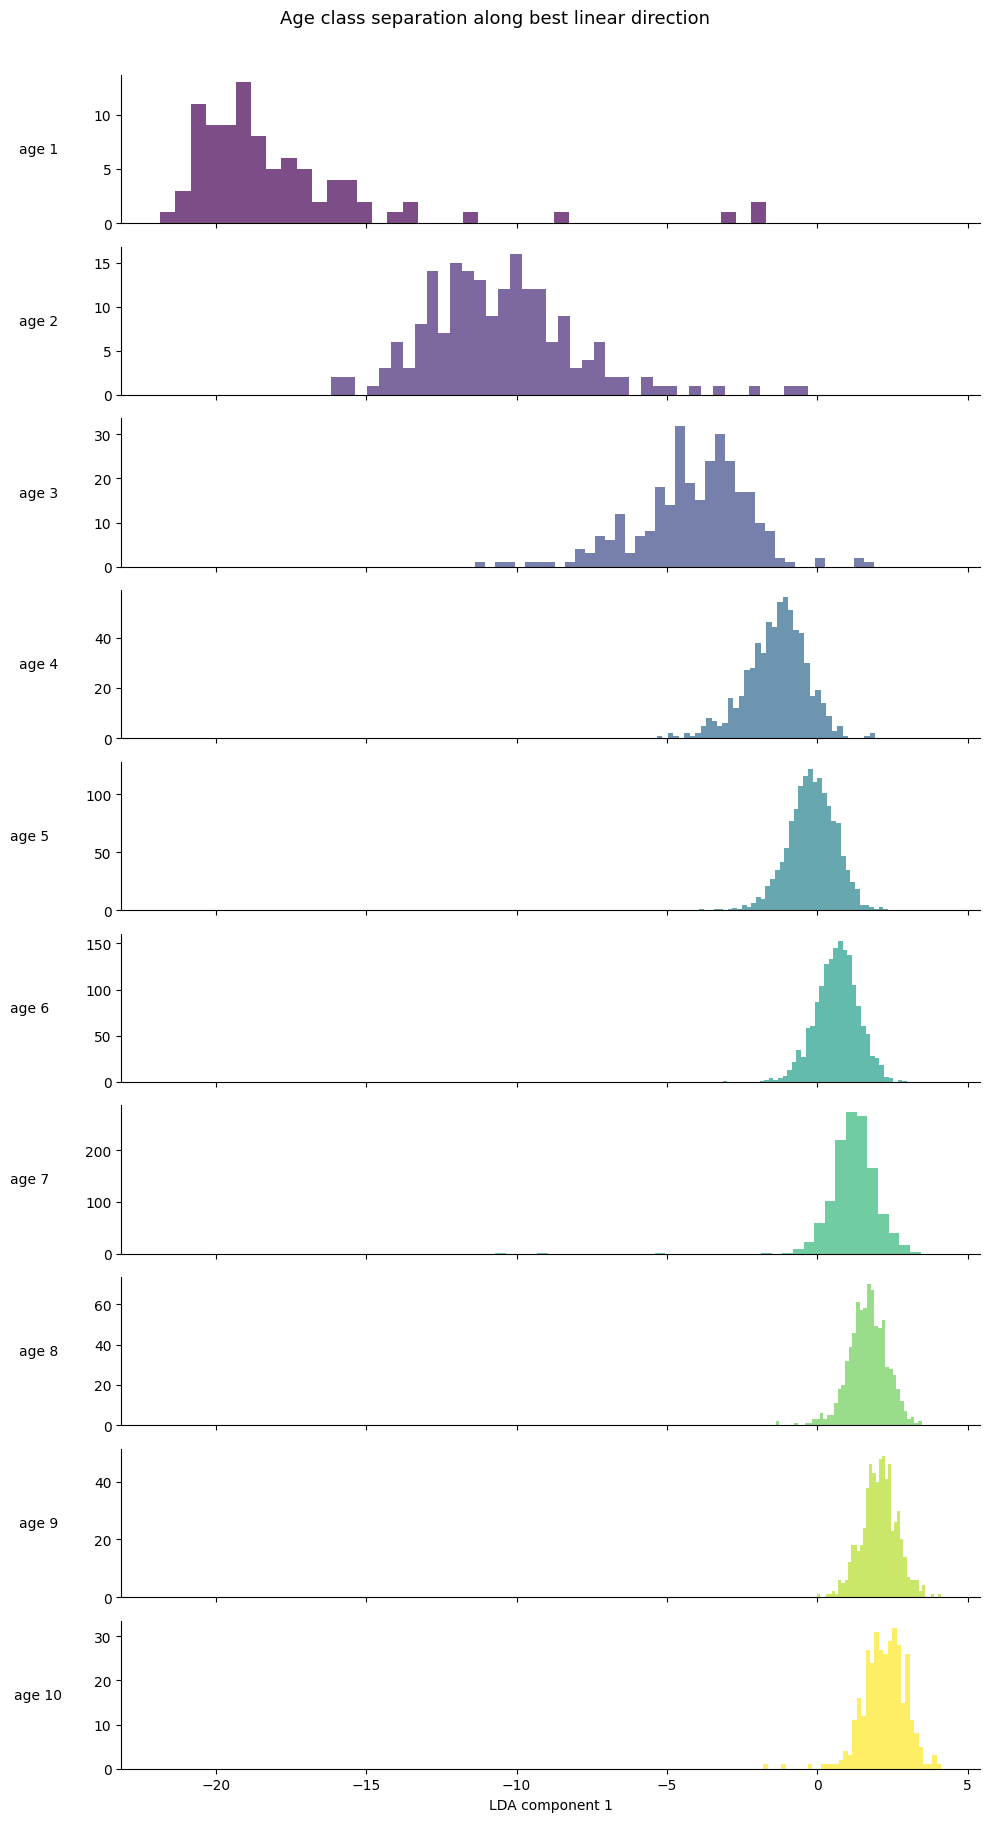

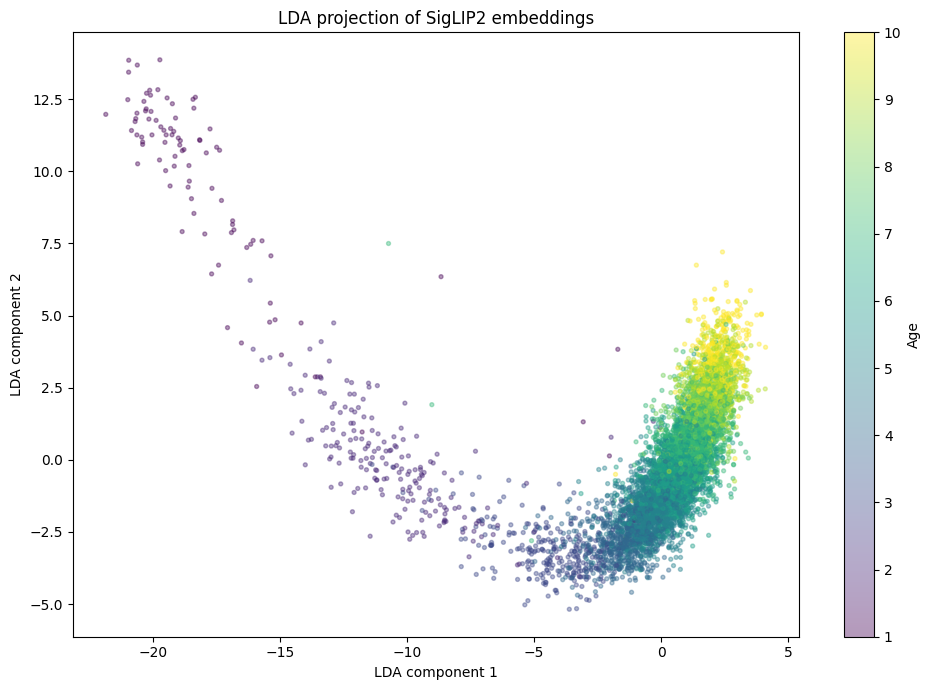

              precision    recall  f1-score   support

           1       1.00      0.69      0.81        16
           2       0.83      0.91      0.87        33
           3       0.78      0.67      0.72        52
           4       0.48      0.51      0.50       114
           5       0.54      0.54      0.54       254
           6       0.46      0.48      0.47       291
           7       0.47      0.51      0.49       222
           8       0.38      0.36      0.37       139
           9       0.48      0.45      0.47       110
          10       0.68      0.55      0.61        62

    accuracy                           0.51      1293
   macro avg       0.61      0.57      0.58      1293
weighted avg       0.51      0.51      0.51      1293

              precision    recall  f1-score   support

           1       0.53      0.50      0.52        16
           2       0.65      0.61      0.62        33
           3       0.49      0.40      0.44        52
           4       0.46 

In [42]:
lda = LinearDiscriminantAnalysis(n_components=9)
X_lda = lda.fit_transform(X_train, y_train)

# 1. The most important plot: component 1 alone
# This is the single best linear age separator
fig, axes = plt.subplots(10, 1, figsize=(10, 18), sharex=True)

for i, age_class in enumerate(sorted(np.unique(y_train))):
    mask = y_train == age_class
    axes[i].hist(X_lda[mask, 0], bins=40, alpha=0.7,
                 color=plt.cm.viridis(i / 9))
    axes[i].set_ylabel(f"age {age_class}", rotation=0,
                       labelpad=40, va="center")
    axes[i].spines[["top", "right"]].set_visible(False)  # keep left spine

axes[-1].set_xlabel("LDA component 1")
fig.suptitle("Age class separation along best linear direction",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 2. First two components as scatter
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_lda[:, 0], X_lda[:, 1],
                c=y_train, cmap="viridis", alpha=0.4, s=8)
plt.colorbar(sc, label="Age")
ax.set_xlabel("LDA component 1")
ax.set_ylabel("LDA component 2")
ax.set_title("LDA projection of SigLIP2 embeddings")
plt.tight_layout()
plt.show()

y_pred_lda = np.clip(lda.predict(X_test), 1, 10)
print(classification_report(y_test, y_pred_lda))


X_train_lda = lda.transform(X_train)
X_test_lda = lda.transform(X_test)


ridge_on_lda = RidgeCV(
    cv = 5,
    alphas=np.logspace(-1, 3.0, 50)
    ).fit(X_train_lda, y_train)
y_pred = np.clip(np.round(ridge_on_lda.predict(X_test_lda)), 1, 10)

print(classification_report(y_test, y_pred))
print("accuracy:", (y_pred == y_test).mean())
print("macro F1:", f1_score(y_test, y_pred, average="macro"))
print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
print("MAE:", np.mean(np.abs(y_pred - y_test)))

In [10]:
results = []

for n in range(1, 10):
    print("\n#### LDA Classification ####")
    lda = LinearDiscriminantAnalysis(n_components=n)
    lda.fit(X_train, y_train)
    y_pred = np.clip(lda.predict(X_test), 1, 10)
    results.append({
        "n_components": n,
        "accuracy": (y_pred == y_test).mean(),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
    })
    print(f"n={n} | macro F1={results[-1]['macro_f1']:.3f} | acc={results[-1]['accuracy']:.3f}")


    print("\n#### Ridge with LDA features ####")

    X_train_lda = lda.transform(X_train)
    X_test_lda = lda.transform(X_test)


    ridge_on_lda = RidgeCV(
        cv = 5,
        alphas=np.logspace(-1, 3.0, 30)
        ).fit(X_train_lda, y_train)
    print(f"{ridge_on_lda.alpha_=}")
    y_pred = np.clip(np.round(ridge_on_lda.predict(X_test_lda)), 1, 10)

    print(classification_report(y_test, y_pred))
    print("accuracy:", (y_pred == y_test).mean())
    print("macro F1:", f1_score(y_test, y_pred, average="macro"))
    print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
    print("MAE:", np.mean(np.abs(y_pred - y_test)))

    df_lda_results = pd.DataFrame(results)
    print("\n--- Best by macro F1 ---")
    print(df_lda_results.loc[df_lda_results["macro_f1"].idxmax()])


#### LDA Classification ####
n=1 | macro F1=0.584 | acc=0.508

#### Ridge with LDA features ####
ridge_on_lda.alpha_=np.float64(148.73521072935117)
              precision    recall  f1-score   support

           1       0.42      0.88      0.57        16
           2       0.91      0.30      0.45        33
           3       0.64      0.13      0.22        52
           4       0.10      0.02      0.03       114
           5       0.23      0.08      0.12       254
           6       0.31      0.54      0.39       291
           7       0.28      0.73      0.40       222
           8       0.19      0.05      0.08       139
           9       0.00      0.00      0.00       110
          10       0.00      0.00      0.00        62

    accuracy                           0.29      1293
   macro avg       0.31      0.27      0.23      1293
weighted avg       0.25      0.29      0.22      1293

accuracy: 0.29311678267594743
macro F1: 0.2273194382773866
Weighted F1: 0.2199866725275153
M

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


n=2 | macro F1=0.584 | acc=0.508

#### Ridge with LDA features ####
ridge_on_lda.alpha_=np.float64(16.102620275609393)
              precision    recall  f1-score   support

           1       0.12      0.25      0.17        16
           2       0.28      0.21      0.24        33
           3       0.56      0.42      0.48        52
           4       0.48      0.41      0.45       114
           5       0.55      0.42      0.48       254
           6       0.47      0.51      0.49       291
           7       0.44      0.59      0.51       222
           8       0.32      0.46      0.38       139
           9       0.41      0.27      0.33       110
          10       0.85      0.18      0.29        62

    accuracy                           0.44      1293
   macro avg       0.45      0.37      0.38      1293
weighted avg       0.47      0.44      0.44      1293

accuracy: 0.4431554524361949
macro F1: 0.38062881603756277
Weighted F1: 0.44001202590039934
MAE: 0.6527455529775715

--- B

## Pair Plot

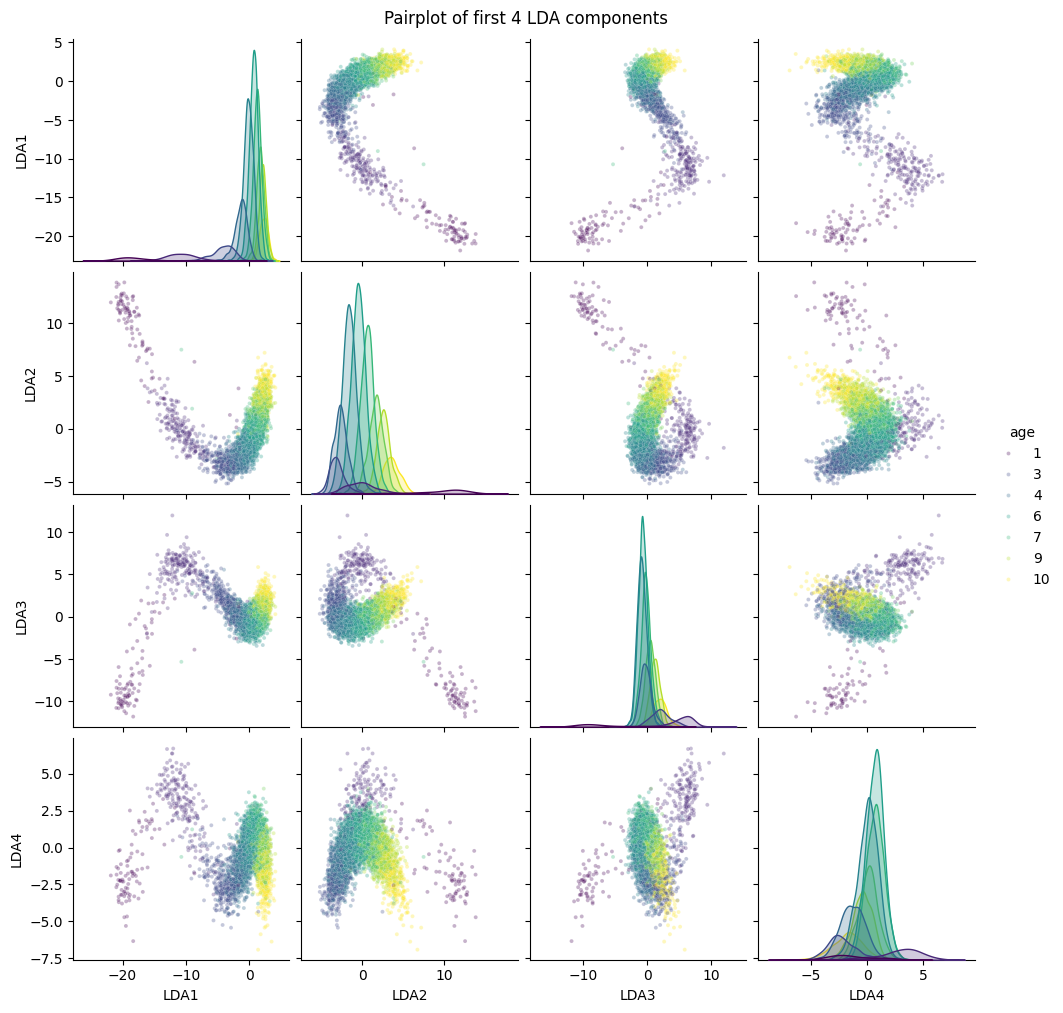

In [42]:
import pandas as pd
import seaborn as sns

# Build dataframe with the first 4 LDA components + age label
sns.pairplot(df_lda[["LDA1", "LDA2", "LDA3", "LDA4", "age"]],
             hue="age", palette="viridis",
             plot_kws={"alpha": 0.3, "s": 8},
             diag_kind="kde")
plt.suptitle("Pairplot of first 4 LDA components", y=1.01)
plt.show()

## Ridge RBF kernel

In [14]:
from sklearn.metrics import pairwise_distances

dist = np.percentile(pairwise_distances(X_train), [25, 50, 75])

In [47]:
from sklearn.kernel_ridge import KernelRidge



# Fit and transform with LDA n_comp = 9

X_train, X_test, y_train, y_test = train_test_split(
    emb, age, test_size=0.15, random_state=81, stratify=age
)

lda = LinearDiscriminantAnalysis(n_components=9)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

# Compute Gamma
[_, med, _] =  np.percentile(pairwise_distances(X_train_lda), [25, 50, 75])
init_gamma = 1/med**2
print(f"{init_gamma=}")

rbf_ridge = KernelRidge(alpha=1.0, kernel="rbf", gamma=init_gamma)
rbf_ridge.fit(X_train_lda, y_train)

y_pred = np.clip(np.round(rbf_ridge.predict(X_test_lda)), 1, 10)

print(classification_report(y_test, y_pred))


init_gamma=np.float64(0.037932658249194944)
              precision    recall  f1-score   support

           1       0.54      0.88      0.67        16
           2       0.66      0.64      0.65        33
           3       0.64      0.54      0.58        52
           4       0.47      0.48      0.48       114
           5       0.54      0.52      0.53       254
           6       0.48      0.57      0.53       291
           7       0.45      0.48      0.46       222
           8       0.36      0.38      0.37       139
           9       0.48      0.36      0.41       110
          10       0.61      0.18      0.28        62

    accuracy                           0.48      1293
   macro avg       0.52      0.50      0.49      1293
weighted avg       0.49      0.48      0.48      1293



### Grid Search SVC

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np


# Compute Gamma
[_, med, _] =  np.percentile(pairwise_distances(X_train_lda), [25, 50, 75])
init_gamma = 1/med**2
print(f"{init_gamma=}")

pipe = Pipeline([
    ("lda", LinearDiscriminantAnalysis(n_components=9)),
    ("svc", SVC(kernel="rbf")),
])

param_grid = {
    "svc__C": [0.1, 1.0, 10.0, 100.0],
    "svc__gamma": [init_gamma * f for f in [0.1, 0.5, 1.0, 2.0, 5.0]],
}

gs = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)

gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print(f"Best CV macro F1: {gs.best_score_:.4f}")

y_pred = gs.predict(X_test)
print(classification_report(y_test, y_pred))

init_gamma=np.float64(0.037932658249194944)
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best params: {'svc__C': 0.1, 'svc__gamma': np.float64(0.018966329124597472)}
Best CV macro F1: 0.5460
              precision    recall  f1-score   support

           1       0.85      0.69      0.76        16
           2       0.83      0.88      0.85        33
           3       0.79      0.63      0.70        52
           4       0.46      0.41      0.43       114
           5       0.52      0.53      0.53       254
           6       0.45      0.51      0.48       291
           7       0.46      0.51      0.48       222
           8       0.35      0.32      0.33       139
           9       0.47      0.43      0.45       110
          10       0.68      0.48      0.57        62

    accuracy                           0.49      1293
   macro avg       0.59      0.54      0.56      1293
weighted avg       0.50      0.49      0.49      1293



## Add Metadata

In [17]:


add_data = meta[["measurement_id", "length", "month_cos", "month_sin", "seg_width_px", "seg_height_px", "seg_aspect_ratio"]].values

add_data


meta['measurement_id'] = pd.Categorical(meta['measurement_id'], categories=meId, ordered=True)

meta_sorted = meta.sort_values('measurement_id').reset_index(drop=True)


add_data_to_merge = meta_sorted[[
    "length", "month_cos", "month_sin",
    "seg_width_px", "seg_height_px", "seg_aspect_ratio"
]].values


X_merged = np.hstack((emb, add_data_to_merge))

print("Shape of original embeddings (emb):", emb.shape)
print("Shape of sorted additional data (add_data_to_merge):", add_data_to_merge.shape)
print("Shape of merged data (X_merged):", X_merged.shape)



X_train, X_test, y_train, y_test = train_test_split(
    X_merged, age, test_size=0.15, random_state=81, stratify=age
)

scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print("Shape of scaled merged data (X_train_sc):", X_train_sc.shape)
print("Shape of scaled merged data (X_test_sc):", X_test_sc.shape)

Shape of original embeddings (emb): (8619, 1152)
Shape of sorted additional data (add_data_to_merge): (8619, 6)
Shape of merged data (X_merged): (8619, 1158)
Shape of scaled merged data (X_train_sc): (7326, 1158)
Shape of scaled merged data (X_test_sc): (1293, 1158)


### Ridge Regression

In [20]:
ridge = RidgeCV(
    cv=5,
    alphas = np.logspace(1, 3, 30)
    ).fit(X_train_sc, y_train)

y_pred = np.clip(np.round(ridge.predict(X_test_sc)), 1, 10)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       0.71      0.62      0.67        16
           2       0.76      0.76      0.76        33
           3       0.80      0.69      0.74        52
           4       0.56      0.60      0.58       114
           5       0.62      0.56      0.59       254
           6       0.56      0.55      0.55       291
           7       0.49      0.61      0.55       222
           8       0.42      0.54      0.47       139
           9       0.49      0.39      0.44       110
          10       0.85      0.37      0.52        62

    accuracy                           0.55      1293
   macro avg       0.63      0.57      0.59      1293
weighted avg       0.57      0.55      0.56      1293



### LDA

              precision    recall  f1-score   support

           1       1.00      0.69      0.81        16
           2       0.83      0.91      0.87        33
           3       0.78      0.67      0.72        52
           4       0.51      0.51      0.51       114
           5       0.58      0.60      0.59       254
           6       0.54      0.53      0.53       291
           7       0.51      0.57      0.54       222
           8       0.37      0.36      0.37       139
           9       0.52      0.50      0.51       110
          10       0.69      0.56      0.62        62

    accuracy                           0.55      1293
   macro avg       0.63      0.59      0.61      1293
weighted avg       0.55      0.55      0.55      1293

Mean max probability: 0.786
% samples with max prob > 0.95: 24.2%
% samples with max prob > 0.80: 52.9%


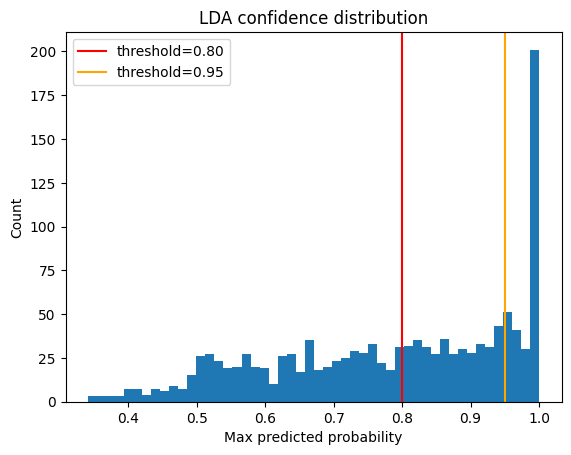

In [ ]:

lda = LinearDiscriminantAnalysis(n_components=9)

X_train_lda = lda.fit_transform(X_train_sc, y_train)

X_test_lda = lda.transform(X_test_sc)
y_pred = lda.predict(X_test_sc)

print(classification_report(y_test, y_pred))


# Check what LDA's raw probabilities actually look like
probs = lda.predict_proba(X_test_sc)

max_probs = probs.max(axis=1)

print(f"Mean max probability: {max_probs.mean():.3f}")
print(f"% samples with max prob > 0.95: {(max_probs > 0.95).mean()*100:.1f}%")
print(f"% samples with max prob > 0.80: {(max_probs > 0.80).mean()*100:.1f}%")


plt.hist(max_probs, bins=50)
plt.axvline(0.80, color='red', label='threshold=0.80')
plt.axvline(0.95, color='orange', label='threshold=0.95')
plt.xlabel('Max predicted probability')
plt.ylabel('Count')
plt.legend()
plt.title('LDA confidence distribution')
plt.show()

### SVC rbf kernel

In [27]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Recompute gamma for raw embedding space
idx = np.random.choice(len(X_train_sc), size=1000, replace=False)
D = pairwise_distances(X_train_sc[idx])
upper = D[np.triu_indices_from(D, k=1)]
median_dist = np.median(upper)
init_gamma = 1 / (median_dist ** 2)
print(f"Embedding-space gamma: {init_gamma:.4f}")

param_grid = {
    "C": [1.0, 10.0, 100.0],
    "gamma": [init_gamma * f for f in [0.5, 1.0, 2.0]],
}

gs = GridSearchCV(
    SVC(kernel="rbf"),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1,
)


gs.fit(X_train_sc, y_train)
print("Best params:", gs.best_params_)
print(f"Best CV macro F1: {gs.best_score_:.4f}")

y_pred = gs.predict(X_test_sc)
print(classification_report(y_test, y_pred))

results_df = pd.DataFrame(gs.cv_results_)
print(results_df[['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']]
      .sort_values('mean_test_score', ascending=False)
      .to_string(index=False))
      

Embedding-space gamma: 0.0005
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'C': 10.0, 'gamma': 0.00023565895441983329}
Best CV macro F1: 0.5908
              precision    recall  f1-score   support

           1       1.00      0.75      0.86        16
           2       0.79      0.94      0.86        33
           3       0.74      0.60      0.66        52
           4       0.54      0.50      0.52       114
           5       0.58      0.63      0.60       254
           6       0.53      0.54      0.53       291
           7       0.47      0.53      0.49       222
           8       0.41      0.40      0.40       139
           9       0.59      0.50      0.54       110
          10       0.70      0.48      0.57        62

    accuracy                           0.55      1293
   macro avg       0.63      0.59      0.60      1293
weighted avg       0.55      0.55      0.55      1293

 param_C  param_gamma  mean_test_score  std_test_score
    10.0     

### Performance Comparison

In [28]:
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV
from sklearn.metrics import f1_score, pairwise_distances
from sklearn.linear_model import RidgeCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
import numpy as np

N_RUNS = 10
sss = StratifiedShuffleSplit(n_splits=N_RUNS, test_size=0.15, random_state=42)

# Gamma on full dataset before loop
idx = np.random.choice(len(X_merged), size=1000, replace=False)
D = pairwise_distances(StandardScaler().fit_transform(X_merged)[idx])
upper = D[np.triu_indices_from(D, k=1)]
init_gamma = 1 / (np.median(upper) ** 2)
print(f"gamma: {init_gamma:.6f}")

ridge_scores, lda_scores, svc_scores = [], [], []

for run, (train_idx, test_idx) in enumerate(sss.split(X_merged, age)):
    X_tr_raw, X_te_raw = X_merged[train_idx], X_merged[test_idx]
    y_tr,     y_te     = age[train_idx],       age[test_idx]
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_raw)
    X_te = scaler.transform(X_te_raw)
    # Ridge
    ridge = RidgeCV(alphas=np.logspace(1, 3, 30), cv=5).fit(X_tr, y_tr)
    y_pred = np.clip(np.round(ridge.predict(X_te)), 1, 10).astype(int)
    ridge_scores.append(f1_score(y_te, y_pred, average='macro'))
    # LDA
    lda = LinearDiscriminantAnalysis(n_components=9).fit(X_tr, y_tr)
    lda_scores.append(f1_score(y_te, lda.predict(X_te), average='macro'))
    # SVC
    param_grid = {
        "C":     [5.0, 10.0, 20.0],              # centred around 10
        "gamma": [init_gamma * f for f in [0.3, 0.5, 0.7]],  # centred around 0.5x
    }
    gs = GridSearchCV(
        SVC(kernel="rbf"),
        param_grid, cv=5, scoring="f1_macro", n_jobs=-1, verbose=1 
        )
    gs.fit(X_tr, y_tr)
    svc_scores.append(f1_score(y_te, gs.predict(X_te), average='macro'))
    print(f"Run {run+1:02d} | Ridge {ridge_scores[-1]:.4f} | LDA {lda_scores[-1]:.4f} | SVC {svc_scores[-1]:.4f} | best: {gs.best_params_}")

results = {
    'Ridge': np.array(ridge_scores),
    'LDA':   np.array(lda_scores),
    'SVC':   np.array(svc_scores),
}
for name, scores in results.items():
    print(f"{name}: {scores.mean():.4f} ± {scores.std():.4f}")

gamma: 0.000465
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Run 01 | Ridge 0.6331 | LDA 0.6374 | SVC 0.6341 | best: {'C': 20.0, 'gamma': 0.00013960909291276018}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Run 02 | Ridge 0.5845 | LDA 0.6134 | SVC 0.6134 | best: {'C': 10.0, 'gamma': 0.00013960909291276018}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Run 03 | Ridge 0.5724 | LDA 0.6095 | SVC 0.6116 | best: {'C': 20.0, 'gamma': 0.00013960909291276018}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Run 04 | Ridge 0.5906 | LDA 0.5754 | SVC 0.5798 | best: {'C': 20.0, 'gamma': 0.00013960909291276018}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Run 05 | Ridge 0.5695 | LDA 0.5965 | SVC 0.5962 | best: {'C': 20.0, 'gamma': 0.00013960909291276018}
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Run 06 | Ridge 0.5857 | LDA 0.5762 | SVC 0.5839 | best: {'C': 10.0, 'gamma': 0.00023268182152126697}
Fitting 5 folds fo

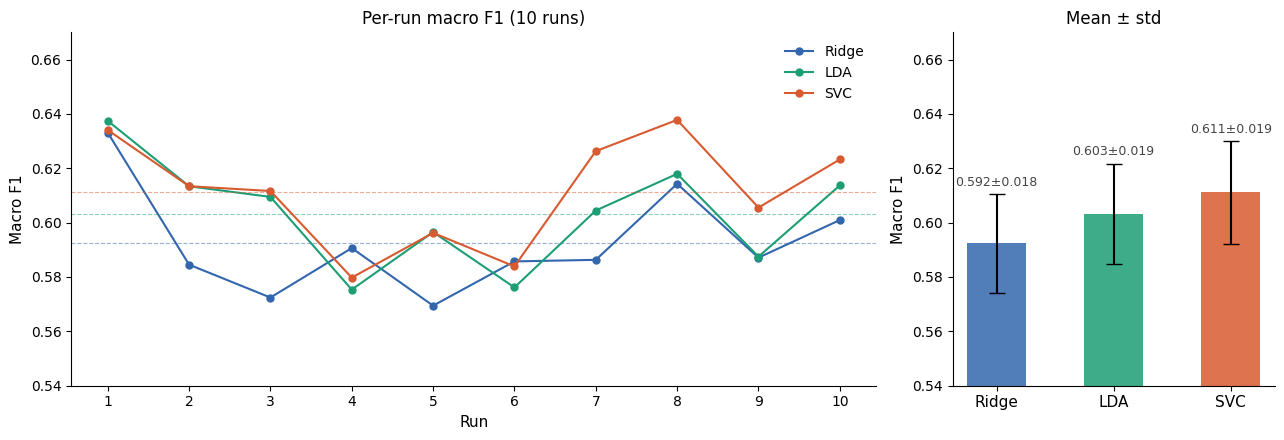

In [29]:
from unittest import result
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ridge = results['Ridge']
lda   = results['LDA']
svc   = results['SVC']

runs = np.arange(1, 11)
colors = {'Ridge': '#3266ad', 'LDA': '#1D9E75', 'SVC': '#D85A30'}
data   = {'Ridge': ridge, 'LDA': lda, 'SVC': svc}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios': [2.5, 1]})

# --- left: per-run lines ---
ax = axes[0]
for name, scores in data.items():
    ax.plot(runs, scores, marker='o', markersize=5, linewidth=1.5,
            color=colors[name], label=name)
    mean = np.mean(scores)
    ax.axhline(mean, color=colors[name], linewidth=0.8, linestyle='--', alpha=0.5)

ax.set_xlabel('Run', fontsize=11)
ax.set_ylabel('Macro F1', fontsize=11)
ax.set_title('Per-run macro F1 (10 runs)', fontsize=12)
ax.set_xticks(runs)
ax.set_ylim(0.54, 0.67)
ax.legend(frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

# --- right: mean ± std boxplot-style ---
ax2 = axes[1]
names = list(data.keys())
means = [np.mean(data[n]) for n in names]
stds  = [np.std(data[n])  for n in names]
x = np.arange(len(names))

ax2.bar(x, means, yerr=stds, capsize=6, width=0.5,
        color=[colors[n] for n in names], alpha=0.85, error_kw={'linewidth': 1.5})

for i, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i, m + s + 0.003, f'{m:.3f}±{s:.3f}', ha='center', fontsize=9,
             color='#444')

ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize=11)
ax2.set_ylabel('Macro F1', fontsize=11)
ax2.set_title('Mean ± std', fontsize=12)
ax2.set_ylim(0.54, 0.67)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('classifier_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Removing Colinearity

In [43]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_merged, age, test_size=0.15, random_state=81, stratify=age
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── Assumes metadata columns are the last k columns of X_merged ──
N_META = meta.shape[1]  # adjust to however many metadata columns you have
emb_train, meta_train = X_train_sc[:, :-N_META], X_train_sc[:, -N_META:]
emb_test,  meta_test  = X_test_sc[:,  :-N_META], X_test_sc[:,  -N_META:]

# ────────────────────────────────────────────────────────────────
# BASELINE: plain LDA
# ────────────────────────────────────────────────────────────────
lda = LinearDiscriminantAnalysis(n_components=9)
lda.fit(X_train_sc, y_train)
y_pred_base = lda.predict(X_test_sc)

print("=== Baseline: LDA ===")
print(classification_report(y_test, y_pred_base))

# ────────────────────────────────────────────────────────────────
# OPTION 1: PCA → LDA
# ────────────────────────────────────────────────────────────────
pca = PCA(n_components=0.95)  # keep 95% of variance
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)
print(f"PCA kept {pca.n_components_} components from {X_train_sc.shape[1]}")

lda_pca = LinearDiscriminantAnalysis(n_components=9)
lda_pca.fit(X_train_pca, y_train)
y_pred_pca = lda_pca.predict(X_test_pca)

print("=== Option 1: PCA → LDA ===")
print(classification_report(y_test, y_pred_pca))

# ────────────────────────────────────────────────────────────────
# OPTION 2: Residualise metadata out of embeddings → LDA
# ────────────────────────────────────────────────────────────────
reg = LinearRegression()
reg.fit(meta_train, emb_train)           # predict embeddings from metadata
resid_train = emb_train - reg.predict(meta_train)  # image-only signal
resid_test  = emb_test  - reg.predict(meta_test)

# Re-attach metadata so LDA still sees it as a separate input
X_train_resid = np.hstack([resid_train, meta_train])
X_test_resid  = np.hstack([resid_test,  meta_test])

lda_resid = LinearDiscriminantAnalysis(n_components=9)
lda_resid.fit(X_train_resid, y_train)
y_pred_resid = lda_resid.predict(X_test_resid)

print("=== Option 2: Residualised embeddings → LDA ===")
print(classification_report(y_test, y_pred_resid))

=== Baseline: LDA ===
              precision    recall  f1-score   support

           1       1.00      0.69      0.81        16
           2       0.83      0.91      0.87        33
           3       0.78      0.67      0.72        52
           4       0.51      0.51      0.51       114
           5       0.58      0.60      0.59       254
           6       0.54      0.53      0.53       291
           7       0.51      0.57      0.54       222
           8       0.37      0.36      0.37       139
           9       0.52      0.50      0.51       110
          10       0.69      0.56      0.62        62

    accuracy                           0.55      1293
   macro avg       0.63      0.59      0.61      1293
weighted avg       0.55      0.55      0.55      1293

PCA kept 164 components from 1158
=== Option 1: PCA → LDA ===
              precision    recall  f1-score   support

           1       1.00      0.69      0.81        16
           2       0.77      0.91      0.83     

### Self Training

In [63]:
from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.calibration import CalibratedClassifierCV
import numpy as np

# ── Create semi-supervised labels ──
# -1 means "unlabelled" to sklearn
def make_semi_supervised_labels(y, labeled_fraction=0.10, random_state=42):
    rng = np.random.default_rng(random_state)
    y_semi = np.full(len(y), -1, dtype=int)
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        n_labeled = max(1, int(len(idx) * labeled_fraction))
        chosen = rng.choice(idx, size=n_labeled, replace=False)
        y_semi[chosen] = y[chosen]
    return y_semi

y_train_semi = make_semi_supervised_labels(y_train, labeled_fraction=0.10)
print(f"Labelled: {(y_train_semi != -1).sum()}, Unlabelled: {(y_train_semi == -1).sum()}")

# ── Self-training wrapper ──
base_lda = LinearDiscriminantAnalysis(n_components=9)

base = CalibratedClassifierCV(
    LinearDiscriminantAnalysis(n_components=9),
    cv=3,
    method='sigmoid'  # or 'sigmoid' — try both
)

self_trainer = SelfTrainingClassifier(
    estimator=base,
    criterion='k_best',
    k_best = 100,
    max_iter=50,
    verbose=True
)

self_trainer.fit(X_train_sc, y_train_semi)
print(classification_report(y_test, self_trainer.predict(X_test_sc)))

Labelled: 728, Unlabelled: 6598
End of iteration 1, added 100 new labels.
End of iteration 2, added 100 new labels.
End of iteration 3, added 100 new labels.
End of iteration 4, added 100 new labels.
End of iteration 5, added 100 new labels.
End of iteration 6, added 100 new labels.
End of iteration 7, added 100 new labels.
End of iteration 8, added 100 new labels.
End of iteration 9, added 100 new labels.
End of iteration 10, added 100 new labels.
End of iteration 11, added 100 new labels.
End of iteration 12, added 100 new labels.
End of iteration 13, added 100 new labels.
End of iteration 14, added 100 new labels.
End of iteration 15, added 100 new labels.
End of iteration 16, added 100 new labels.
End of iteration 17, added 100 new labels.
End of iteration 18, added 100 new labels.
End of iteration 19, added 100 new labels.
End of iteration 20, added 100 new labels.
End of iteration 21, added 100 new labels.
End of iteration 22, added 100 new labels.
End of iteration 23, added 100 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Embedding-space gamma: 0.0005
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best params: {'C': 10.0, 'gamma': 0.00023342761576585652}
Best CV macro F1: 0.5900
              precision    recall  f1-score   support

           1       1.00      0.75      0.86        16
           2       0.79      0.94      0.86        33
           3       0.74      0.60      0.66        52
           4       0.54      0.50      0.52       114
           5       0.58      0.63      0.60       254
           6       0.53      0.54      0.53       291
           7       0.47      0.53      0.49       222
           8       0.41      0.40      0.40       139
           9       0.59      0.50      0.54       110
          10       0.70      0.48      0.57        62

    accuracy                           0.55      1293
   macro avg       0.63      0.59      0.60      1293
weighted avg       0.55      0.55      0.55      1293



# Linear Regression

In [ ]:


def analyze_age_direction(embeddings, labels):
    # Identify extreme ages
    unique_ages = np.unique(labels)
    min_age, max_age = np.min(unique_ages), np.max(unique_ages)

    # Calculate extreme means
    proto_young = embeddings[labels == min_age].mean(axis=0)
    proto_old = embeddings[labels == max_age].mean(axis=0)

    # Normalized Age Vector
    age_direction = proto_old - proto_young
    age_direction /= np.linalg.norm(age_direction)

    # Projection of ALL embeddings on this axis
    # (Dot product between each vector and the age vector)
    projections = dot_product = np.dot(embeddings, age_direction)

    # Compute the residuals (removing age signal)
    # residual = original - (projection * direction)
    age_components = np.outer(projections, age_direction)
    residuals = embeddings - age_components

    return age_direction, projections, residuals



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


emb_train, emb_test, y_train, y_test = train_test_split(
    emb, age, test_size=0.15, random_state=42, stratify=age
)

def get_age_direction(e, l):
    p_young = e[l == l.min()].mean(axis=0)
    p_old = e[l == l.max()].mean(axis=0)
    d = p_old - p_young
    return d / np.linalg.norm(d)

age_dir = get_age_direction(emb_train, y_train)

# 3. Gerar Scores (Projeção)
train_scores = np.dot(emb_train, age_dir).reshape(-1, 1)
test_scores = np.dot(emb_test, age_dir).reshape(-1, 1)

# 4. Treinar Regressão
reg = LinearRegression().fit(train_scores, y_train)

# 5. Avaliação Final
preds_test = reg.predict(test_scores)
class_pred = np.clip(np.round(preds_test), 1, 10)
mae = mean_absolute_error(y_test, preds_test)
acc = accuracy_score(y_test, class_pred)
print(f"Erro Médio no Test Set: {mae:.2f} anos")
print(f"Acurácia no Test Set: {acc*100:.2f}%")



Erro Médio no Test Set: 1.10 anos
Acurácia no Test Set: 29.54%


In [ ]:
 from sklearn.linear_model import RidgeCV
 from sklearn.preprocessing import StandardScaler

# 1. Limpar os dados (Ponto 4)
mean_proto = emb_train.mean(axis=0)
X_train_res = emb_train - mean_proto
X_test_res = emb_test - mean_proto

scaler = StandardScaler().fit(X_train_res)
X_train_res = scaler.transform(X_train_res)
X_test_res = scaler.transform(X_test_res)


# 2. Treinar Ridge (Regressão Linear Robusta)
# O parâmetro alpha controla a regularização. 1.0 é um bom começo.
model_ridge = RidgeCV(alphas= np.logspace(1, 3, 50))
model_ridge.fit(X_train_res, y_train)
print(f"{model_ridge.alpha_}")

# 3. Avaliar
preds_ridge = model_ridge.predict(X_test_res)
mae_ridge = mean_absolute_error(y_test, preds_ridge)
acc_ridge = accuracy_score(y_test, np.clip(np.round(preds_ridge), y.min(), y.max()))

print(f"Ridge com Resíduos - MAE: {mae_ridge:.2f}")
print(f"Ridge com Resíduos - Acurácia: {acc_ridge*100:.2f}%")


429.1934260128778
Ridge com Resíduos - MAE: 0.61
Ridge com Resíduos - Acurácia: 51.28%


In [ ]:
from sklearn.svm import SVR

# SVR costuma beneficiar de dados normalizados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(emb_train)
X_test_scaled = scaler.transform(emb_test)

model_svr = SVR(kernel='rbf', C=10, epsilon=0.1)
model_svr.fit(X_train_scaled, y_train)

preds_svr = model_svr.predict(X_test_scaled)
mae_svr = mean_absolute_error(y_test, preds_svr)
acc_svr = accuracy_score(y_test, np.clip(np.round(preds_svr), y.min(), y.max()))


print(f"SVR com Resíduos - MAE: {mae_svr:.2f}")
print(f"SVR com Resíduos - Acurácia: {acc_svr*100:.2f}%")

SVR com Resíduos - MAE: 0.63
SVR com Resíduos - Acurácia: 49.19%


# Residualize Embeddings Against Image Size

In [ ]:
size = meta[['seg_width_px', 'seg_height_px']].values


# 3. Fit a linear regression: predict each embedding feature from size
#    This learns 1152 separate linear equations, one per feature:
#      feature_i = β₀ + β₁·width + β₂·height
reg = LinearRegression().fit(size, emb)

# 4. Get what size "predicts" for each embedding feature
emb_pred = reg.predict(size)

# 5. The residuals = actual - predicted
#    This is what's LEFT after removing the size effect
res = emb - emb_pred





In [ ]:
from sklearn.linear_model import LassoCV
rs = 81

# Train
X_train, X_test, y_train, y_test = train_test_split(
    emb,
    age,
    test_size=0.15,
    random_state = rs)

scaler = StandardScaler().fit(X_train)
X_train_sc, X_test_sc = scaler.transform(X_train), scaler.transform(X_test)

lasso = LassoCV(
    cv=5,
    random_state=rs,
    max_iter=10000
    ).fit(X_train_sc, y_train)

# Testing
lasso.score(X_test_sc, y_test)

y_pred = np.clip(np.round(lasso.predict(X_test_sc)), 0, 10)
accuracy = accuracy_score(y_test, y_pred)
mae = np.mean(np.abs(y_pred-y_test))
f1 = f1_score(y_test, y_pred, average = "macro")


print(f"{accuracy=}")
print(f"{f1=}")
print(f"{mae=}")

accuracy=0.4934261407579273
f1=0.42681948467246494
mae=np.float64(0.5754060324825986)


In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import accuracy_score, f1_score

rs = 81

# Train
X_train, X_test, y_train, y_test = train_test_split(
    res,
    age,
    test_size=0.15,
    random_state = rs)

scaler = StandardScaler().fit(X_train)
X_train_sc, X_test_sc = scaler.transform(X_train), scaler.transform(X_test)

lasso = LassoCV(
    cv=5,
    random_state=rs,
    max_iter=10000
    ).fit(X_train_sc, y_train)

# Testing
lasso.score(X_test_sc, y_test)

y_pred = np.clip(np.round(lasso.predict(X_test_sc)), 0, 10)
accuracy = accuracy_score(y_test, y_pred)
mae = np.mean(np.abs(y_pred-y_test))
f1 = f1_score(y_test, y_pred, average = "macro")


print(f"{accuracy=}")
print(f"{f1=}")
print(f"{mae=}")

accuracy=0.4833720030935808
f1=0.42223342180571566
mae=np.float64(0.5870069605568445)


In [ ]:
meta['measurement_id'] = pd.Categorical(meta['measurement_id'], categories=meId, ordered=True)
meta_sorted = meta.sort_values('measurement_id').reset_index(drop=True)

meta_sorted = meta_sorted.drop(columns=['measurement_id', "month", "age"]).values
meta_sorted

X = np.hstack((res, meta_sorted))

# Train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    age,
    test_size=0.15,
    random_state = 88)

scaler = StandardScaler().fit(X_train)
X_train_sc, X_test_sc = scaler.transform(X_train), scaler.transform(X_test)

lasso = RidgeCV(
    cv=5,
    alphas = np.logspace(1, 3, 30)
    ).fit(X_train_sc, y_train)

# Testing
lasso.score(X_test_sc, y_test)

y_pred = np.clip(np.round(lasso.predict(X_test_sc)), 0, 10)
accuracy = accuracy_score(y_test, y_pred)
mae = np.mean(np.abs(y_pred-y_test))
f1 = f1_score(y_test, y_pred, average = "macro")


print(f"{accuracy=}")
print(f"{f1=}")
print(f"{mae=}")

accuracy=0.5421500386697602
f1=0.5649760388879607
mae=np.float64(0.4980665119876257)


In [ ]:
meta['measurement_id'] = pd.Categorical(meta['measurement_id'], categories=meId, ordered=True)
meta_sorted = meta.sort_values('measurement_id').reset_index(drop=True)

meta_sorted = meta_sorted.drop(columns=['measurement_id', "month", "age"]).values
meta_sorted

X = np.hstack((emb, meta_sorted))

# Train
X_train, X_test, y_train, y_test = train_test_split(
    X,
    age,
    test_size=0.15,
    random_state = 88)

scaler = StandardScaler().fit(X_train)
X_train_sc, X_test_sc = scaler.transform(X_train), scaler.transform(X_test)

lasso = RidgeCV(
    cv=5,
    alphas = np.logspace(1, 3, 30)
    ).fit(X_train_sc, y_train)

# Testing
lasso.score(X_test_sc, y_test)

y_pred = np.clip(np.round(lasso.predict(X_test_sc)), 0, 10)
accuracy = accuracy_score(y_test, y_pred)
mae = np.mean(np.abs(y_pred-y_test))
f1 = f1_score(y_test, y_pred, average = "macro")


print(f"{accuracy=}")
print(f"{f1=}")
print(f"{mae=}")

accuracy=0.54292343387471
f1=0.5585602977266841
mae=np.float64(0.49729311678267596)
